In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
house_data = pd.read_csv("/Users/ashishkrsingh/Developers/Machine Learning/Projects/House-Price-Prediction/data/train.csv")

# Data Cleaning & Preprocessing

In [ ]:
X = house_data.drop(columns=["Price_INR_Lakhs"])
y = house_data["Price_INR_Lakhs"]

In [ ]:
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (80000, 17)
y shape: (80000,)


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (64000, 17)
X_test shape: (16000, 17)
y_train shape: (64000,)
y_test shape: (16000,)


In [ ]:
print(f"Price_INR_Lakhs in X_train: {"Price_INR_Lakhs" in X_train.columns}")
print(f"Price_INR_Lakhs in X_test: {"Price_INR_Lakhs" in X_test.columns}")

Price_INR_Lakhs in X_train: False
Price_INR_Lakhs in X_test: False


In [ ]:
print("Overlapping rows:",
      len(X_train.index.intersection(X_test.index)))

Overlapping rows: 0


In [ ]:
print("Training Target: ")
print(y_train.describe())
print("Test Target: ")
print(y_test.describe())

Training Target: 
count    64000.000000
mean       142.569400
std        146.851710
min          2.765306
25%         54.330000
50%         96.660000
75%        176.910000
max       3334.915208
Name: Price_INR_Lakhs, dtype: float64
Test Target: 
count    16000.000000
mean       142.786967
std        148.799930
min          5.000000
25%         54.385000
50%         96.460000
75%        175.790000
max       3216.463936
Name: Price_INR_Lakhs, dtype: float64


In [ ]:
X_train = X_train.drop(columns=["Property_ID"])
X_test = X_test.drop(columns=["Property_ID"])

In [ ]:
print(X_train.shape)
print(X_test.shape)

(64000, 16)
(16000, 16)


In [ ]:
print(X_train.dtypes)

City                              str
Locality_Type                     str
Property_Type                     str
BHK                             int64
Bathrooms                       int64
Super_Area_SqFt               float64
Carpet_Area_SqFt              float64
Floor_Number                    int64
Total_Floors                    int64
Age_of_Property                 int64
Furnishing_Status                 str
Parking                         int64
Lift_Available                  int64
Gated_Community                 int64
Distance_to_Metro_km          float64
Distance_to_City_Center_km    float64
dtype: object


In [ ]:
print("Numerical Features: ")
print(X_train.select_dtypes(include="number").columns.to_list())

print("Categorical Features: ")
print(X_train.select_dtypes(include="object").columns.to_list())

Numerical Features: 
['BHK', 'Bathrooms', 'Super_Area_SqFt', 'Carpet_Area_SqFt', 'Floor_Number', 'Total_Floors', 'Age_of_Property', 'Parking', 'Lift_Available', 'Gated_Community', 'Distance_to_Metro_km', 'Distance_to_City_Center_km']
Categorical Features: 
['City', 'Locality_Type', 'Property_Type', 'Furnishing_Status']


/var/folders/48/37lxyrbs3ng58hgh5rjygz3h0000gn/T/ipykernel_1096/423578896.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X_train.select_dtypes(include="object").columns.to_list())


In [ ]:
missing = X_train.isnull().sum()
print(missing)

print("\nColumns with missing values:")
print(missing[missing > 0])

City                          0
Locality_Type                 0
Property_Type                 0
BHK                           0
Bathrooms                     0
Super_Area_SqFt               0
Carpet_Area_SqFt              0
Floor_Number                  0
Total_Floors                  0
Age_of_Property               0
Furnishing_Status             0
Parking                       0
Lift_Available                0
Gated_Community               0
Distance_to_Metro_km          0
Distance_to_City_Center_km    0
dtype: int64

Columns with missing values:
Series([], dtype: int64)


In [ ]:
categorical_features = X_train.select_dtypes(include="object").columns.to_list()

for columns in categorical_features:
    print(f"\n{columns}")
    print(X_train[columns].value_counts())


City
City
Chennai       6537
Bangalore     6533
Mumbai        6446
Hyderabad     6445
Delhi         6420
Ahmedabad     6405
Jaipur        6381
Kolkata       6301
Chandigarh    6279
Pune          6253
Name: count, dtype: int64

Locality_Type
Locality_Type
Mid-Range     32143
Affordable    16028
Premium       15829
Name: count, dtype: int64

Property_Type
Property_Type
Builder Floor        16068
Apartment            15991
Villa                15973
Independent House    15968
Name: count, dtype: int64

Furnishing_Status
Furnishing_Status
Furnished         21550
Semi-Furnished    21354
Unfurnished       21096
Name: count, dtype: int64


/var/folders/48/37lxyrbs3ng58hgh5rjygz3h0000gn/T/ipykernel_1096/1287721223.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include="object").columns.to_list()


In [ ]:
categorical_features = X_train.select_dtypes(include="object").columns

for column in categorical_features:
    train_categories = set(X_train[column].unique())
    test_categories = set(X_test[column].unique())

    print(f"\n{column}")
    print("Categories only in test:",
          test_categories - train_categories)


City
Categories only in test: set()

Locality_Type
Categories only in test: set()

Property_Type
Categories only in test: set()

Furnishing_Status
Categories only in test: set()


/var/folders/48/37lxyrbs3ng58hgh5rjygz3h0000gn/T/ipykernel_1096/1782415003.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include="object").columns


In [ ]:
numerical_features = X_train.select_dtypes(include="number").columns.to_list()
categorical_features = X_train.select_dtypes(include="object").columns.to_list()

print("Numerical Features: ", numerical_features)
print("Number of Numerical Features: ", len(numerical_features))
print("Categorical Features: ", categorical_features)
print("Number of Categorical Features: ", len(categorical_features))

Numerical Features:  ['BHK', 'Bathrooms', 'Super_Area_SqFt', 'Carpet_Area_SqFt', 'Floor_Number', 'Total_Floors', 'Age_of_Property', 'Parking', 'Lift_Available', 'Gated_Community', 'Distance_to_Metro_km', 'Distance_to_City_Center_km']
Number of Numerical Features:  12
Categorical Features:  ['City', 'Locality_Type', 'Property_Type', 'Furnishing_Status']
Number of Categorical Features:  4


/var/folders/48/37lxyrbs3ng58hgh5rjygz3h0000gn/T/ipykernel_1096/1660226892.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include="object").columns.to_list()


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train[numerical_features])

StandardScaler()

In [ ]:
print(scaler.mean_)
print(scaler.scale_)

[2.83520313e+00 3.32006250e+00 1.40929446e+03 1.05697350e+03
 1.07546875e+01 2.24492969e+01 1.94304063e+01 6.55437500e-01
 9.47562500e-01 5.46140625e-01 3.12599438e+00 9.01246969e+00]
[1.30339033e+00 1.35045039e+00 6.36534436e+02 4.86160959e+02
 9.82054176e+00 1.27484837e+01 1.15154150e+01 4.75225403e-01
 2.22907623e-01 4.97866491e-01 1.82325950e+00 3.92287319e+00]


In [ ]:
X_train_numerical_scaled = scaler.transform(X_train[numerical_features])

In [ ]:
print(X_train_numerical_scaled.shape)

(64000, 12)


In [ ]:
print(X_train_numerical_scaled.mean(axis=0))
print(X_train_numerical_scaled.std(axis=0))

[-4.28546088e-17 -1.11910481e-16  1.61648472e-16  1.19793064e-16
  7.92699240e-17 -1.36113343e-16 -7.88258347e-17 -2.84217094e-17
  7.34967642e-17 -1.25233157e-16 -1.78301818e-16  1.44106949e-16]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
X_test_numerical_scaled = scaler.transform(X_test[numerical_features])

In [ ]:
print(X_test_numerical_scaled.shape)

(16000, 12)


In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
encoder = OneHotEncoder(handle_unknown="ignore")

In [ ]:
encoder.fit(X_train[categorical_features])

,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infrequen

In [ ]:
print(encoder.categories_)

[array(['Ahmedabad', 'Bangalore', 'Chandigarh', 'Chennai', 'Delhi',
       'Hyderabad', 'Jaipur', 'Kolkata', 'Mumbai', 'Pune'], dtype=object), array(['Affordable', 'Mid-Range', 'Premium'], dtype=object), array(['Apartment', 'Builder Floor', 'Independent House', 'Villa'],
      dtype=object), array(['Furnished', 'Semi-Furnished', 'Unfurnished'], dtype=object)]


In [ ]:
X_train_categorical_encoded = encoder.transform(X_train[categorical_features])

In [ ]:
print(X_train_categorical_encoded.shape)

(64000, 20)


In [ ]:
X_test_categorical_encoded = encoder.transform(X_test[categorical_features])

In [ ]:
print(X_test_categorical_encoded.shape)

(16000, 20)


In [ ]:
encoded_features_names = encoder.get_feature_names_out(categorical_features)

print(encoded_features_names)
print(f"Number of Encoded Features: {len(encoded_features_names)}")

['City_Ahmedabad' 'City_Bangalore' 'City_Chandigarh' 'City_Chennai'
 'City_Delhi' 'City_Hyderabad' 'City_Jaipur' 'City_Kolkata' 'City_Mumbai'
 'City_Pune' 'Locality_Type_Affordable' 'Locality_Type_Mid-Range'
 'Locality_Type_Premium' 'Property_Type_Apartment'
 'Property_Type_Builder Floor' 'Property_Type_Independent House'
 'Property_Type_Villa' 'Furnishing_Status_Furnished'
 'Furnishing_Status_Semi-Furnished' 'Furnishing_Status_Unfurnished']
Number of Encoded Features: 20


In [ ]:
print("Scaled numerical shape:", X_train_numerical_scaled.shape)
print("Encoded categorical shape:", X_train_categorical_encoded.shape)

print(
    "Total features:",
    X_train_numerical_scaled.shape[1]
    + X_train_categorical_encoded.shape[1]
)

Scaled numerical shape: (64000, 12)
Encoded categorical shape: (64000, 20)
Total features: 32


In [ ]:
X_train_processed = np.hstack((X_train_numerical_scaled, X_train_categorical_encoded.toarray()))

In [ ]:
X_test_processed = np.hstack((X_test_numerical_scaled, X_test_categorical_encoded.toarray()))

In [ ]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(64000, 32)
(16000, 32)


In [ ]:
print("NaN in X_train:", np.isnan(X_train_processed).sum())
print("NaN in X_test:", np.isnan(X_test_processed).sum())

print("Inf in X_train:", np.isinf(X_train_processed).sum())
print("Inf in X_test:", np.isinf(X_test_processed).sum())

NaN in X_train: 0
NaN in X_test: 0
Inf in X_train: 0
Inf in X_test: 0


In [ ]:
processed_feature_names = (
    numerical_features
    + list(encoded_features_names)
)

print("Number of feature names:", len(processed_feature_names))
print(processed_feature_names)

Number of feature names: 32
['BHK', 'Bathrooms', 'Super_Area_SqFt', 'Carpet_Area_SqFt', 'Floor_Number', 'Total_Floors', 'Age_of_Property', 'Parking', 'Lift_Available', 'Gated_Community', 'Distance_to_Metro_km', 'Distance_to_City_Center_km', 'City_Ahmedabad', 'City_Bangalore', 'City_Chandigarh', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Jaipur', 'City_Kolkata', 'City_Mumbai', 'City_Pune', 'Locality_Type_Affordable', 'Locality_Type_Mid-Range', 'Locality_Type_Premium', 'Property_Type_Apartment', 'Property_Type_Builder Floor', 'Property_Type_Independent House', 'Property_Type_Villa', 'Furnishing_Status_Furnished', 'Furnishing_Status_Semi-Furnished', 'Furnishing_Status_Unfurnished']


In [ ]:
print("Columns: ", X_train_processed.shape[1])
print("Features Name: ", len(processed_feature_names))

Columns:  32
Features Name:  32


# Linear Regression

In [ ]:
X_train_bias = np.c_[np.ones(X_train_processed.shape[0]),X_train_processed]

In [ ]:
X_test_bias = np.c_[np.ones(X_test_processed.shape[0]),X_test_processed]

In [ ]:
print(f"X_train_bias.shape: {X_train_bias.shape}")
print(f"X_test_bias.shape: {X_test_bias.shape}")

X_train_bias.shape: (64000, 33)
X_test_bias.shape: (16000, 33)


In [ ]:
class LinearRegression():

    def __init__(self):
        self.theta = None

    def fit(self, X, y):
        # Calculate theta using the Normal Equation
        self.theta = np.linalg.inv(X.T @ X) @ X.T @ y

    def predict(self, X):
        return X @ self.theta

In [ ]:
model = LinearRegression()
model.fit(X_train_bias, y_train)

In [ ]:
print(model.theta)
print("Number of parameters:", len(model.theta))

[ 6.08088433e+18 -2.57929149e+04  2.47772064e+04 -5.88766189e+05
  5.87839457e+05 -3.27964444e+03 -6.41713030e+03  1.36234635e+03
 -1.15842229e+04  2.29769094e+04 -1.47548088e+03  1.15014152e+03
  5.48205577e+01 -7.54014788e+17 -7.54014788e+17 -7.54014788e+17
 -7.54014788e+17 -7.54014788e+17 -7.54014788e+17 -7.54014788e+17
 -7.54014788e+17 -7.54014788e+17 -7.54014788e+17 -5.42658329e+18
 -5.42658329e+18 -5.42658329e+18  9.97137412e+16  9.97137412e+16
  9.97137412e+16  9.97137412e+16 -1.55241220e+03 -1.61668108e+03
 -1.12205262e+03]
Number of parameters: 33


In [ ]:
y_pred = model.predict(X_test_bias)

In [ ]:
print(y_pred.shape)
print(y_pred[:10])

(16000,)
[-3.10163027e+05 -2.94870183e+02  3.17440000e+04 -9.61280000e+04
  7.38560000e+04 -2.15808000e+05 -2.19898983e+04 -6.16410133e+03
 -1.83152000e+05 -9.82588508e+04]


In [ ]:
errors = y_test - y_pred

In [ ]:
print(errors[:10])
print("Mean Error: ", np.mean(errors))

47044    310496.756944
44295       406.960183
74783    -31677.100000
70975     96158.080000
46645    -73678.510000
8215     215928.970000
65509     22338.408331
62715      6317.051330
39859    183273.860000
58834     98432.690813
Name: Price_INR_Lakhs, dtype: float64
Mean Error:  -2558.257576016648


In [ ]:
print("Number of columns:", X_train_bias.shape[1])
print("Matrix rank:", np.linalg.matrix_rank(X_train_bias))

Number of columns: 33
Matrix rank: 29


In [ ]:
encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore"
)

encoder.fit(X_train[categorical_features])

encoded_feature_names = encoder.get_feature_names_out(
    categorical_features
)

print(encoded_feature_names)
print("Number of encoded features:", len(encoded_feature_names))

['City_Bangalore' 'City_Chandigarh' 'City_Chennai' 'City_Delhi'
 'City_Hyderabad' 'City_Jaipur' 'City_Kolkata' 'City_Mumbai' 'City_Pune'
 'Locality_Type_Mid-Range' 'Locality_Type_Premium'
 'Property_Type_Builder Floor' 'Property_Type_Independent House'
 'Property_Type_Villa' 'Furnishing_Status_Semi-Furnished'
 'Furnishing_Status_Unfurnished']
Number of encoded features: 16


In [ ]:
X_train_categorical_encoded = encoder.transform(
    X_train[categorical_features]
)

print(X_train_categorical_encoded.shape)

(64000, 16)


In [ ]:
X_test_categorical_encoded = encoder.transform(
    X_test[categorical_features]
)

print(X_test_categorical_encoded.shape)

(16000, 16)


In [ ]:
X_train_processed = np.hstack([
    X_train_numerical_scaled,
    X_train_categorical_encoded.toarray()
])

print(X_train_processed.shape)

(64000, 28)


In [ ]:
X_test_processed = np.hstack([
    X_test_numerical_scaled,
    X_test_categorical_encoded.toarray()
])

print(X_test_processed.shape)

(16000, 28)


In [ ]:
X_train_bias = np.c_[np.ones((X_train_processed.shape[0])), X_train_processed]

In [ ]:
X_test_bias = np.c_[np.ones(X_test_processed.shape[0]),X_test_processed]

In [ ]:
print("X_train_with_bias:", X_train_bias.shape)
print("X_test_with_bias:", X_test_bias.shape)

print("Number of columns:",
      X_train_bias.shape[1])

print("Matrix rank:",
      np.linalg.matrix_rank(X_train_bias))

X_train_with_bias: (64000, 29)
X_test_with_bias: (16000, 29)
Number of columns: 29
Matrix rank: 29


In [ ]:
model = LinearRegression()

model.fit(
    X_train_bias,
    y_train
)

In [ ]:
print("Number of parameters:", len(model.theta))
print(model.theta)

Number of parameters: 29
[ 4.93984260e+01 -7.14411717e-01  2.11616744e-01  7.08056059e+01
 -1.38898415e+00  6.62364726e-02 -2.15601254e-01 -1.59164013e+01
  1.55388711e+00  1.19031896e+00  1.56161325e+00  8.79745990e-01
 -1.33535818e+01  7.54896657e+01  5.20209455e+01  4.70312346e+01
  1.52463210e+02  4.13554679e+01 -1.02175688e+01  2.41522833e+01
  2.32133222e+02  5.82104053e+01  9.79978590e+00  8.06476133e+01
  2.02071183e-01 -2.97964431e-01  1.14950586e+00 -4.57440929e-01
  2.10384749e+00]


In [ ]:
y_pred = model.predict(X_test_bias)

In [ ]:
errors = y_test - y_pred
print(errors[:10])
print("Mean Error: ", np.mean(errors))

47044    -54.792630
44295     41.108658
74783     31.159514
70975    -18.300130
46645     17.254164
8215      34.881116
65509     35.262257
62715    -20.011009
39859   -106.226955
58834      9.885283
Name: Price_INR_Lakhs, dtype: float64
Mean Error:  0.43808554551618717


In [ ]:
mae = np.mean(np.abs(errors))
print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 47.94025405073612


In [ ]:
mse = np.mean(errors ** 2)
rmse = np.sqrt(mse)
print("Root Mean Square Error (RMSE):", rmse)

Root Mean Square Error (RMSE): 86.0255021547906


In [ ]:
ssr = np.sum(errors ** 2)
tss = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / tss)
print("R-squared:", r2)

R-squared: 0.6657463774890664


In [ ]:
abs_errors = np.abs(errors.to_numpy())

largest_error_indices = np.argsort(abs_errors)[-10:][::-1]

print(abs_errors[largest_error_indices])

[2666.51426689 1692.81141374 1656.80531094 1576.86940361 1489.5410502
 1426.09377353 1373.651024   1222.48279151 1162.86688389 1153.08925131]


In [ ]:
largest_error_rows = X_test.iloc[largest_error_indices].copy()

largest_error_rows["Actual_Price"] = y_test.iloc[
    largest_error_indices
].values

largest_error_rows["Predicted_Price"] = y_pred[
    largest_error_indices
]

largest_error_rows["Absolute_Error"] = abs_errors[
    largest_error_indices
]

print(largest_error_rows)

            City Locality_Type  Property_Type  BHK  Bathrooms  \
29399     Mumbai       Premium          Villa    2          2   
27989     Mumbai       Premium  Builder Floor    6          6   
76198      Delhi       Premium          Villa    2          3   
28319     Mumbai       Premium  Builder Floor    4          5   
70498      Delhi       Premium          Villa    2          2   
5784      Mumbai       Premium      Apartment    4          5   
48752      Delhi       Premium      Apartment    2          3   
15940     Mumbai     Mid-Range  Builder Floor    2          3   
65667  Bangalore       Premium  Builder Floor    3          3   
31684      Delhi       Premium      Apartment    5          6   

       Super_Area_SqFt  Carpet_Area_SqFt  Floor_Number  Total_Floors  \
29399          2821.13           2388.03            29            35   
27989          1970.04           1426.31            18            27   
76198          2533.38           2033.48             8            16

In [ ]:
worst_predictions = house_data.loc[largest_error_rows.index].copy()

worst_predictions["Predicted_Price"] = y_pred[largest_error_indices]
worst_predictions["Absolute_Error"] = abs_errors[largest_error_indices]

print(worst_predictions)

       Property_ID       City Locality_Type  Property_Type  BHK  Bathrooms  \
29399  PROP-033829     Mumbai       Premium          Villa    2          2   
27989  PROP-035444     Mumbai       Premium  Builder Floor    6          6   
76198  PROP-001081      Delhi       Premium          Villa    2          3   
28319  PROP-006071     Mumbai       Premium  Builder Floor    4          5   
70498  PROP-024198      Delhi       Premium          Villa    2          2   
5784   PROP-016730     Mumbai       Premium      Apartment    4          5   
48752  PROP-008681      Delhi       Premium      Apartment    2          3   
15940  PROP-008532     Mumbai     Mid-Range  Builder Floor    2          3   
65667  PROP-080228  Bangalore       Premium  Builder Floor    3          3   
31684  PROP-021175      Delhi       Premium      Apartment    5          6   

       Super_Area_SqFt  Carpet_Area_SqFt  Floor_Number  Total_Floors  \
29399          2821.13           2388.03            29            35 

In [ ]:
for name, coefficient in zip(
    ["Intercept"] + processed_feature_names,
    model.theta
):
    print(f"{name}: {coefficient}")

Intercept: 49.398426036861345
BHK: -0.7144117169493328
Bathrooms: 0.21161674420013968
Super_Area_SqFt: 70.80560591340733
Carpet_Area_SqFt: -1.3889841540907917
Floor_Number: 0.0662364726495305
Total_Floors: -0.21560125413691938
Age_of_Property: -15.916401279123408
Parking: 1.5538871149200673
Lift_Available: 1.1903189575973938
Gated_Community: 1.561613252542932
Distance_to_Metro_km: 0.8797459897807316
Distance_to_City_Center_km: -13.353581820132538
City_Ahmedabad: 75.4896656753646
City_Bangalore: 52.02094549291417
City_Chandigarh: 47.031234569345955
City_Chennai: 152.46321041036668
City_Delhi: 41.35546785519619
City_Hyderabad: -10.21756881390125
City_Jaipur: 24.152283255422407
City_Kolkata: 232.13322154268818
City_Mumbai: 58.21040531780834
City_Pune: 9.799785902257392
Locality_Type_Affordable: 80.64761331614733
Locality_Type_Mid-Range: 0.20207118299254276
Locality_Type_Premium: -0.29796443118964744
Property_Type_Apartment: 1.1495058562000882
Property_Type_Builder Floor: -0.45744092936984

In [ ]:
condition_number = np.linalg.cond(
    X_train_bias.T @ X_train_bias
)

print("Condition number:", condition_number)

Condition number: 231.1372861808773


In [ ]:
carpet_index = numerical_features.index("Carpet_Area_SqFt")

X_train_no_carpet = np.delete(
    X_train_processed,
    carpet_index,
    axis=1
)

X_test_no_carpet = np.delete(
    X_test_processed,
    carpet_index,
    axis=1
)

print(X_train_no_carpet.shape)
print(X_test_no_carpet.shape)

(64000, 27)
(16000, 27)


In [ ]:
model_no_carpet = LinearRegression()

model_no_carpet.fit(
    X_train_no_carpet,
    y_train.to_numpy()
)

In [ ]:
y_pred_no_carpet = model_no_carpet.predict(
    X_test_no_carpet
)

In [ ]:
errors_no_carpet = y_test.to_numpy() - y_pred_no_carpet

mae_no_carpet = np.mean(np.abs(errors_no_carpet))

mse_no_carpet = np.mean(errors_no_carpet ** 2)
rmse_no_carpet = np.sqrt(mse_no_carpet)

ss_res_no_carpet = np.sum(errors_no_carpet ** 2)
ss_tot = np.sum(
    (y_test.to_numpy() - np.mean(y_test.to_numpy())) ** 2
)

r2_no_carpet = 1 - (ss_res_no_carpet / ss_tot)

print("MAE:", mae_no_carpet)
print("RMSE:", rmse_no_carpet)
print("R²:", r2_no_carpet)

MAE: 49.37475836897388
RMSE: 86.78183963919092
R²: 0.6598430142801086


In [ ]:
print("Condition number of X:",
      np.linalg.cond(X_train_bias))

Condition number of X: 15.20319986650434


In [ ]:
y_train_log = np.log1p(y_train.to_numpy())

print(y_train_log[:10])

[3.79952597 4.66258968 4.85771719 3.72665682 4.64169496 4.57047522
 3.18221184 5.098463   3.7882722  5.40587048]


In [ ]:
model_log = LinearRegression()

model_log.fit(
    X_train_bias,
    y_train_log
)

In [ ]:
print("Number of parameters:", len(model_log.theta))

Number of parameters: 29


In [ ]:
y_pred_log = model_log.predict(X_test_bias)

print(y_pred_log[:10])

[6.20340847 4.38169745 3.81627687 3.93961289 4.86710146 4.49268694
 5.73171351 4.64479666 5.01140023 4.98290162]


In [ ]:
y_pred_log_original = np.expm1(y_pred_log)

In [ ]:
errors_log_model = y_test.to_numpy() - y_pred_log_original

mae_log_model = np.mean(np.abs(errors_log_model))

mse_log_model = np.mean(errors_log_model ** 2)
rmse_log_model = np.sqrt(mse_log_model)

y_test_array = y_test.to_numpy()
y_mean = np.mean(y_test_array)

ss_res = np.sum((y_test_array - y_pred_log_original) ** 2)
ss_tot = np.sum((y_test_array - y_mean) ** 2)

r2_log_model = 1 - (ss_res / ss_tot)

print("MAE :", mae_log_model)
print("RMSE:", rmse_log_model)
print("R²  :", r2_log_model)

MAE : 34.8199306273559
RMSE: 74.63420330962622
R²  : 0.748407614822956


In [ ]:
abs_errors_log_model = np.abs(
    y_test.to_numpy() - y_pred_log_original
)

largest_error_indices_log = np.argsort(
    abs_errors_log_model
)[-10:][::-1]

print(abs_errors_log_model[largest_error_indices_log])

[2148.38209959 1638.49332863 1534.66098517 1489.83780987 1406.47468154
 1322.81407478 1221.45927069 1168.02149435 1100.57288686 1022.80575399]


In [ ]:
worst_log_predictions = X_test.iloc[
    largest_error_indices_log
].copy()

worst_log_predictions["Actual_Price"] = y_test.iloc[
    largest_error_indices_log
].values

worst_log_predictions["Predicted_Price"] = y_pred_log_original[
    largest_error_indices_log
]

worst_log_predictions["Absolute_Error"] = abs_errors_log_model[
    largest_error_indices_log
]

print(
    worst_log_predictions[
        [
            "City",
            "Locality_Type",
            "Super_Area_SqFt",
            "Actual_Price",
            "Predicted_Price",
            "Absolute_Error"
        ]
    ]
)

            City Locality_Type  Super_Area_SqFt  Actual_Price  \
29399     Mumbai       Premium          2821.13   3216.463936   
27989     Mumbai       Premium          1970.04   2118.077564   
76198      Delhi       Premium          2533.38   2066.850917   
28319     Mumbai       Premium          2116.70   2015.136967   
70498      Delhi       Premium          2604.39   1888.725648   
48752      Delhi       Premium          2164.92   1744.789814   
15940     Mumbai     Mid-Range          1588.83   1564.522651   
5784      Mumbai       Premium          2743.20   1922.444303   
65667  Bangalore       Premium          2526.23   1519.327700   
31684      Delhi       Premium          2488.40   1563.814016   

       Predicted_Price  Absolute_Error  
29399      1068.081836     2148.382100  
27989       479.584235     1638.493329  
76198       532.189932     1534.660985  
28319       525.299157     1489.837810  
70498       482.250966     1406.474682  
48752       421.975739     1322.814075

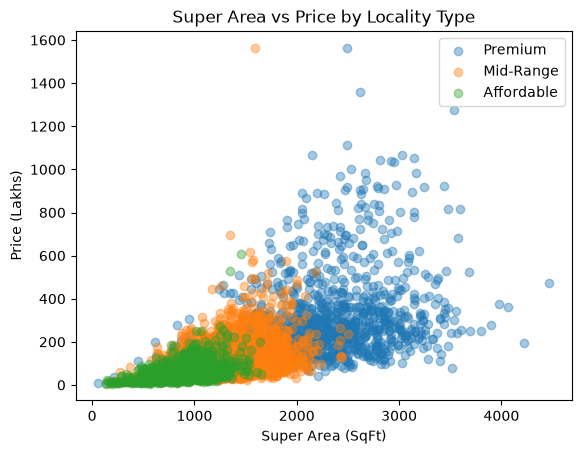

In [ ]:
import matplotlib.pyplot as plt

plot_data = house_data.sample(
    n=5000,
    random_state=42
)

for locality in plot_data["Locality_Type"].unique():

    subset = plot_data[
        plot_data["Locality_Type"] == locality
    ]

    plt.scatter(
        subset["Super_Area_SqFt"],
        subset["Price_INR_Lakhs"],
        label=locality,
        alpha=0.4
    )

plt.xlabel("Super Area (SqFt)")
plt.ylabel("Price (Lakhs)")
plt.title("Super Area vs Price by Locality Type")
plt.legend()
plt.show()

In [ ]:
area_index = processed_feature_names.index("Super_Area_SqFt")

locality_indices = [
    i for i, name in enumerate(processed_feature_names)
    if name.startswith("Locality_Type_")
]

print("Area index:", area_index)
print("Locality indices:", locality_indices)

print([
    processed_feature_names[i]
    for i in locality_indices
])

Area index: 2
Locality indices: [22, 23, 24]
['Locality_Type_Affordable', 'Locality_Type_Mid-Range', 'Locality_Type_Premium']


In [ ]:
print(encoder.drop)
print(encoder.get_feature_names_out(categorical_features))
print(X_train_processed.shape)

first
['City_Bangalore' 'City_Chandigarh' 'City_Chennai' 'City_Delhi'
 'City_Hyderabad' 'City_Jaipur' 'City_Kolkata' 'City_Mumbai' 'City_Pune'
 'Locality_Type_Mid-Range' 'Locality_Type_Premium'
 'Property_Type_Builder Floor' 'Property_Type_Independent House'
 'Property_Type_Villa' 'Furnishing_Status_Semi-Furnished'
 'Furnishing_Status_Unfurnished']
(64000, 28)


In [ ]:
area_index = processed_feature_names.index("Super_Area_SqFt")

mid_range_index = processed_feature_names.index(
    "Locality_Type_Mid-Range"
)

premium_index = processed_feature_names.index(
    "Locality_Type_Premium"
)

# Create interaction features
train_area_mid = (
    X_train_processed[:, area_index]
    * X_train_processed[:, mid_range_index]
)

train_area_premium = (
    X_train_processed[:, area_index]
    * X_train_processed[:, premium_index]
)

test_area_mid = (
    X_test_processed[:, area_index]
    * X_test_processed[:, mid_range_index]
)

test_area_premium = (
    X_test_processed[:, area_index]
    * X_test_processed[:, premium_index]
)

In [ ]:
print(train_area_mid[:10])
print(train_area_premium[:10])

[-0. -0.  0. -0. -0.  0. -0.  0. -0.  0.]
[-0.         -0.          0.         -0.         -0.99406163  0.
 -0.          0.881375   -1.01332218  0.        ]


In [ ]:
X_train_interaction = np.column_stack([
    X_train_processed,
    train_area_mid,
    train_area_premium
])

X_test_interaction = np.column_stack([
    X_test_processed,
    test_area_mid,
    test_area_premium
])

print(X_train_interaction.shape)
print(X_test_interaction.shape)

(64000, 30)
(16000, 30)


In [ ]:
X_train_interaction_bias = np.c_[
    np.ones(X_train_interaction.shape[0]),
    X_train_interaction
]

X_test_interaction_bias = np.c_[
    np.ones(X_test_interaction.shape[0]),
    X_test_interaction
]

print(X_train_interaction_bias.shape)
print(X_test_interaction_bias.shape)

(64000, 31)
(16000, 31)


In [ ]:
model_interaction = LinearRegression()

model_interaction.fit(
    X_train_interaction_bias,
    y_train.to_numpy()
)

In [ ]:
y_pred_interaction = model_interaction.predict(
    X_test_interaction_bias
)

print(y_pred_interaction[:10])

[390.65704729  71.30021178  34.82181516  48.64338951 161.1684978
  86.27103923 312.72541506 172.80406349 226.13958507 164.19593054]


In [ ]:
errors_interaction = (
    y_test.to_numpy() - y_pred_interaction
)

mae_interaction = np.mean(
    np.abs(errors_interaction)
)

mse_interaction = np.mean(
    errors_interaction ** 2
)

rmse_interaction = np.sqrt(mse_interaction)

y_test_array = y_test.to_numpy()
y_mean = np.mean(y_test_array)

ss_res = np.sum(
    (y_test_array - y_pred_interaction) ** 2
)

ss_tot = np.sum(
    (y_test_array - y_mean) ** 2
)

r2_interaction = 1 - (ss_res / ss_tot)

print("MAE :", mae_interaction)
print("RMSE:", rmse_interaction)
print("R²  :", r2_interaction)

MAE : 47.946949681853205
RMSE: 86.01363957291726
R²  : 0.6658385556798937


In [ ]:
print("Area × Mid-Range coefficient:",
      model_interaction.theta[-2])

print("Area × Premium coefficient:",
      model_interaction.theta[-1])

Area × Mid-Range coefficient: -1.9333190481453255
Area × Premium coefficient: -1.1339683448821232


In [ ]:
area_index = processed_feature_names.index("Super_Area_SqFt")

train_area_squared = (
    X_train_processed[:, area_index] ** 2
)

test_area_squared = (
    X_test_processed[:, area_index] ** 2
)

print(train_area_squared[:10])
print(test_area_squared[:10])

[0.97909046 0.22623822 0.67412037 0.28000349 0.98815853 0.45775852
 0.88260227 0.7768219  1.02682183 4.20829867]
[7.93733043 0.67869146 1.33394221 0.4642201  0.62631671 0.29261187
 1.83466875 0.18521863 2.7126262  0.1206469 ]


In [ ]:
X_train_polynomial = np.column_stack([
    X_train_processed,
    train_area_squared
])

X_test_polynomial = np.column_stack([
    X_test_processed,
    test_area_squared
])

print(X_train_polynomial.shape)
print(X_test_polynomial.shape)

(64000, 29)
(16000, 29)


In [ ]:
X_train_polynomial_bias = np.c_[
    np.ones(X_train_polynomial.shape[0]),
    X_train_polynomial
]

X_test_polynomial_bias = np.c_[
    np.ones(X_test_polynomial.shape[0]),
    X_test_polynomial
]

print(X_train_polynomial_bias.shape)
print(X_test_polynomial_bias.shape)

(64000, 30)
(16000, 30)


In [ ]:
model_polynomial = LinearRegression()

model_polynomial.fit(
    X_train_polynomial_bias,
    y_train.to_numpy()
)

In [ ]:
y_pred_polynomial = model_polynomial.predict(
    X_test_polynomial_bias
)

print(y_pred_polynomial[:10])

[413.62102757  77.63236371  40.28546368  52.5195284  166.16518562
  88.59378339 308.41803653 163.95150944 227.32122513 159.43498044]


In [ ]:
errors_polynomial = (
    y_test.to_numpy() - y_pred_polynomial
)

mae_polynomial = np.mean(
    np.abs(errors_polynomial)
)

mse_polynomial = np.mean(
    errors_polynomial ** 2
)

rmse_polynomial = np.sqrt(mse_polynomial)

y_test_array = y_test.to_numpy()
y_mean = np.mean(y_test_array)

ss_res = np.sum(
    (y_test_array - y_pred_polynomial) ** 2
)

ss_tot = np.sum(
    (y_test_array - y_mean) ** 2
)

r2_polynomial = 1 - (ss_res / ss_tot)

print("MAE :", mae_polynomial)
print("RMSE:", rmse_polynomial)
print("R²  :", r2_polynomial)

MAE : 47.155004526692416
RMSE: 85.74559766067381
R²  : 0.6679179866134404


In [ ]:
print("Area coefficient:",
      model_polynomial.theta[1 + area_index])

print("Area² coefficient:",
      model_polynomial.theta[-1])

Area coefficient: 64.32003006949532
Area² coefficient: 6.483429586889666


In [ ]:
error_analysis = X_test.copy()
error_analysis["Absolute_Error"] = np.abs(
    y_test.to_numpy() - y_pred_log_original
)

In [ ]:
error_analysis["Actual_Price"] = y_test.to_numpy()
error_analysis["Predicted_Price"] = y_pred_log_original

In [ ]:
error_analysis.groupby("Locality_Type")["Absolute_Error"].agg(["mean", "count"])

,mean,count
Locality_Type,,
Affordable,14.305028,3944
Mid-Range,25.901279,8100
Premium,73.533745,3956


In [ ]:
error_analysis["Relative_Error"] = (
    error_analysis["Absolute_Error"]
    / error_analysis["Actual_Price"]
)

relative_error_by_locality = (
    error_analysis
    .groupby("Locality_Type")["Relative_Error"]
    .agg(["mean", "count"])
)

relative_error_by_locality["mean"] *= 100

print(relative_error_by_locality)

                    mean  count
Locality_Type                  
Affordable     27.430436   3944
Mid-Range      24.695793   8100
Premium        26.438029   3956


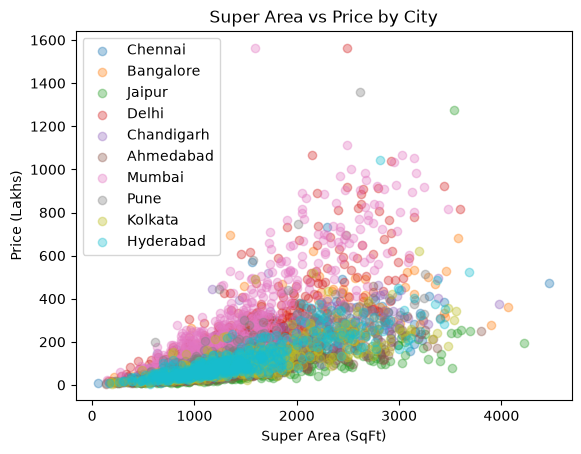

In [ ]:
import matplotlib.pyplot as plt

plot_data_city = house_data.sample(
    n=5000,
    random_state=42
)

for city in plot_data_city["City"].unique():

    subset = plot_data_city[
        plot_data_city["City"] == city
    ]

    plt.scatter(
        subset["Super_Area_SqFt"],
        subset["Price_INR_Lakhs"],
        label=city,
        alpha=0.35
    )

plt.xlabel("Super Area (SqFt)")
plt.ylabel("Price (Lakhs)")
plt.title("Super Area vs Price by City")
plt.legend()
plt.show()

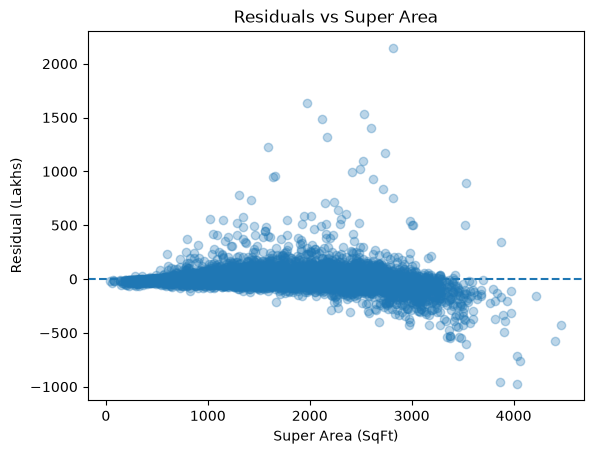

In [ ]:
residuals_log = (
    y_test.to_numpy() - y_pred_log_original
)

plt.scatter(
    X_test["Super_Area_SqFt"],
    residuals_log,
    alpha=0.3
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Super Area (SqFt)")
plt.ylabel("Residual (Lakhs)")
plt.title("Residuals vs Super Area")
plt.show()

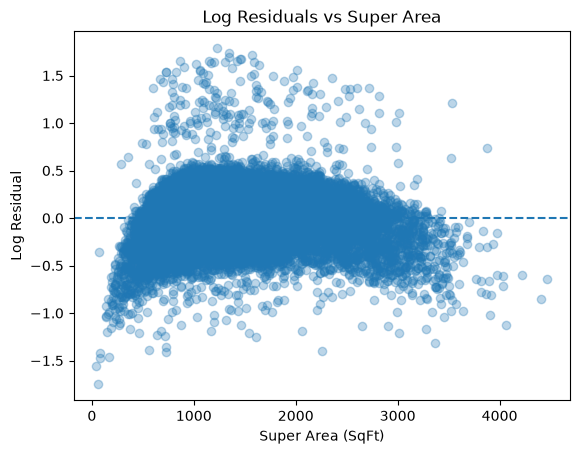

In [ ]:
y_test_log = np.log1p(y_test.to_numpy())

residuals_log_space = (
    y_test_log - y_pred_log
)

plt.scatter(
    X_test["Super_Area_SqFt"],
    residuals_log_space,
    alpha=0.3
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Super Area (SqFt)")
plt.ylabel("Log Residual")
plt.title("Log Residuals vs Super Area")
plt.show()


In [ ]:
area_index = processed_feature_names.index("Super_Area_SqFt")
train_area_squared = (
    X_train_processed[:, area_index] ** 2
)

test_area_squared = (
    X_test_processed[:, area_index] ** 2
)

X_train_log_poly = np.column_stack([
    X_train_processed,
    train_area_squared
])

X_test_log_poly = np.column_stack([
    X_test_processed,
    test_area_squared
])

print(X_train_log_poly.shape)
print(X_test_log_poly.shape)

(64000, 29)
(16000, 29)


In [ ]:
X_train_log_poly_bias = np.c_[
    np.ones(X_train_log_poly.shape[0]),
    X_train_log_poly
]

X_test_log_poly_bias = np.c_[
    np.ones(X_test_log_poly.shape[0]),
    X_test_log_poly
]

print(X_train_log_poly_bias.shape)
print(X_test_log_poly_bias.shape)

(64000, 30)
(16000, 30)


In [ ]:
model_log_poly = LinearRegression()

model_log_poly.fit(
    X_train_log_poly_bias,
    y_train_log
)

In [ ]:
y_pred_log_poly = model_log_poly.predict(
    X_test_log_poly_bias
)

print(y_pred_log_poly[:10])

[5.85890354 4.29040438 3.75389172 3.88279479 4.78571419 4.45830426
 5.7980069  4.76846261 5.02191078 5.04494031]


In [ ]:
y_pred_log_poly_original = np.expm1(
    y_pred_log_poly
)

print(y_pred_log_poly_original[:10])

[349.33980146  71.99598093  41.68688442  47.5597399  118.78688308
  85.34097264 328.64189394 116.7380932  150.70089355 154.23503219]


In [ ]:
errors_log_poly = (
    y_test.to_numpy() - y_pred_log_poly_original
)

mae_log_poly = np.mean(
    np.abs(errors_log_poly)
)

mse_log_poly = np.mean(
    errors_log_poly ** 2
)

rmse_log_poly = np.sqrt(mse_log_poly)

y_test_array = y_test.to_numpy()
y_mean = np.mean(y_test_array)

ss_res = np.sum(
    (y_test_array - y_pred_log_poly_original) ** 2
)

ss_tot = np.sum(
    (y_test_array - y_mean) ** 2
)

r2_log_poly = 1 - (ss_res / ss_tot)

print("MAE :", mae_log_poly)
print("RMSE:", rmse_log_poly)
print("R²  :", r2_log_poly)

MAE : 32.165145731949615
RMSE: 68.42698737918154
R²  : 0.7885164803918998


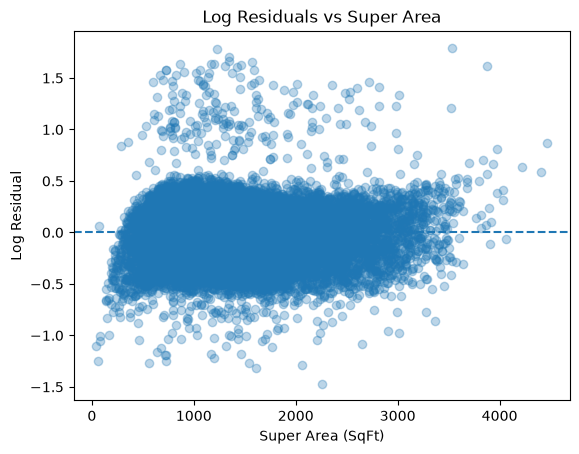

In [ ]:
y_test_log = np.log1p(y_test.to_numpy())

residuals_log_space = (
    y_test_log - y_pred_log_poly
)

plt.scatter(
    X_test["Super_Area_SqFt"],
    residuals_log_space,
    alpha=0.3
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Super Area (SqFt)")
plt.ylabel("Log Residual")
plt.title("Log Residuals vs Super Area")
plt.show()


In [ ]:
residuals_log_poly = (
    y_test_log - y_pred_log_poly
)

largest_positive_indices = np.argsort(
    residuals_log_poly
)[-10:][::-1]

print(
    residuals_log_poly[largest_positive_indices]
)

[1.79457182 1.779099   1.70486341 1.66106014 1.6535749  1.63627595
 1.63557471 1.63417185 1.62170761 1.61610528]


In [ ]:
worst_underpredictions = X_test.iloc[
    largest_positive_indices
].copy()

worst_underpredictions["Actual_Price"] = y_test.iloc[
    largest_positive_indices
].values

worst_underpredictions["Predicted_Price"] = (
    y_pred_log_poly_original[
        largest_positive_indices
    ]
)

worst_underpredictions["Log_Residual"] = (
    residuals_log_poly[
        largest_positive_indices
    ]
)

columns_to_inspect = [
    "City",
    "Locality_Type",
    "Property_Type",
    "Furnishing_Status",
    "BHK",
    "Bathrooms",
    "Super_Area_SqFt",
    "Carpet_Area_SqFt",
    "Age_of_Property",
    "Distance_to_Metro_km",
    "Distance_to_City_Center_km",
    "Actual_Price",
    "Predicted_Price",
    "Log_Residual"
]

print(
    worst_underpredictions[
        columns_to_inspect
    ]
)

             City Locality_Type      Property_Type Furnishing_Status  BHK  \
38615      Jaipur       Premium              Villa    Semi-Furnished    2   
64310     Kolkata     Mid-Range      Builder Floor         Furnished    2   
36391   Bangalore     Mid-Range              Villa         Furnished    5   
78870  Chandigarh     Mid-Range  Independent House       Unfurnished    3   
21084        Pune     Mid-Range              Villa       Unfurnished    2   
57066  Chandigarh     Mid-Range          Apartment    Semi-Furnished    1   
71588        Pune    Affordable      Builder Floor    Semi-Furnished    2   
32393     Chennai     Mid-Range  Independent House    Semi-Furnished    1   
2615       Jaipur     Mid-Range      Builder Floor       Unfurnished    2   
19909       Delhi     Mid-Range              Villa       Unfurnished    4   

       Bathrooms  Super_Area_SqFt  Carpet_Area_SqFt  Age_of_Property  \
38615          2          3537.00           2853.14               10   
64310   

In [ ]:
worst_underpredictions["Price_per_SqFt"] = (
    worst_underpredictions["Actual_Price"]
    / worst_underpredictions["Super_Area_SqFt"]
)

print(
    worst_underpredictions[
        [
            "City",
            "Locality_Type",
            "Super_Area_SqFt",
            "Actual_Price",
            "Price_per_SqFt",
            "Predicted_Price",
            "Log_Residual"
        ]
    ]
)

             City Locality_Type  Super_Area_SqFt  Actual_Price  \
38615      Jaipur       Premium          3537.00   1273.405455   
64310     Kolkata     Mid-Range          1232.02    370.829540   
36391   Bangalore     Mid-Range          1345.21    695.981526   
78870  Chandigarh     Mid-Range          1347.39    587.647781   
21084        Pune     Mid-Range          1573.12    581.968660   
57066  Chandigarh     Mid-Range          1172.17    443.654146   
71588        Pune    Affordable           866.82    242.414413   
32393     Chennai     Mid-Range          1193.19    480.127915   
2615       Jaipur     Mid-Range          1461.75    308.604359   
19909       Delhi     Mid-Range          1303.09    964.677266   

       Price_per_SqFt  Predicted_Price  Log_Residual  
38615        0.360024       210.804402      1.794572  
64310        0.300993        61.761167      1.779099  
36391        0.517378       125.709301      1.704863  
78870        0.436138       110.806295      1.661060 

In [ ]:
house_data["Price_per_SqFt"] = (
    house_data["Price_INR_Lakhs"]
    / house_data["Super_Area_SqFt"]
)

city_locality_price = (
    house_data
    .groupby(["City", "Locality_Type"])["Price_per_SqFt"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

print(city_locality_price)

                              mean  count
City       Locality_Type                 
Mumbai     Premium        0.280237   1975
Delhi      Premium        0.209037   1965
Mumbai     Mid-Range      0.191666   4045
           Affordable     0.144313   2004
Delhi      Mid-Range      0.141466   4048
Bangalore  Premium        0.135475   2019
Pune       Premium        0.120771   1956
Chandigarh Premium        0.113891   1981
Chennai    Premium        0.110015   2036
Delhi      Affordable     0.106224   2024
Hyderabad  Premium        0.105512   1960
Bangalore  Mid-Range      0.094690   4160
Kolkata    Premium        0.089999   1936
Pune       Mid-Range      0.082600   3973
Chandigarh Mid-Range      0.079806   3907
Chennai    Mid-Range      0.076513   4107
Hyderabad  Mid-Range      0.072716   4083
Bangalore  Affordable     0.069848   2010
Ahmedabad  Premium        0.069057   2028
Pune       Affordable     0.062267   1904
Kolkata    Mid-Range      0.061468   3952
Chandigarh Affordable     0.059694

In [ ]:
house_data.drop(
    columns=["Price_per_SqFt"],
    inplace=True
)

In [ ]:
city_indices = [
    i for i, name in enumerate(processed_feature_names)
    if name.startswith("City_")
]

locality_indices = [
    i for i, name in enumerate(processed_feature_names)
    if name.startswith("Locality_Type_")
]

print("City indices:", city_indices)
print("City features:", [
    processed_feature_names[i]
    for i in city_indices
])

print("Locality indices:", locality_indices)
print("Locality features:", [
    processed_feature_names[i]
    for i in locality_indices
])

City indices: [12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
City features: ['City_Ahmedabad', 'City_Bangalore', 'City_Chandigarh', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Jaipur', 'City_Kolkata', 'City_Mumbai', 'City_Pune']
Locality indices: [22, 23, 24]
Locality features: ['Locality_Type_Affordable', 'Locality_Type_Mid-Range', 'Locality_Type_Premium']


In [ ]:
train_city_locality = []

test_city_locality = []

for city_index in city_indices:

    for locality_index in locality_indices:

        train_interaction = (
            X_train_processed[:, city_index]
            * X_train_processed[:, locality_index]
        )

        test_interaction = (
            X_test_processed[:, city_index]
            * X_test_processed[:, locality_index]
        )

        train_city_locality.append(train_interaction)
        test_city_locality.append(test_interaction)

train_city_locality = np.column_stack(
    train_city_locality
)

test_city_locality = np.column_stack(
    test_city_locality
)

print(train_city_locality.shape)
print(test_city_locality.shape)

(64000, 30)
(16000, 30)


In [ ]:
print("City count:", len(city_indices))
print("Locality count:", len(locality_indices))

print("City indices:", city_indices)
print("Locality indices:", locality_indices)

print("City features:")
print([
    processed_feature_names[i]
    for i in city_indices
])

print("Locality features:")
print([
    processed_feature_names[i]
    for i in locality_indices
])

City count: 10
Locality count: 3
City indices: [12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
Locality indices: [22, 23, 24]
City features:
['City_Ahmedabad', 'City_Bangalore', 'City_Chandigarh', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Jaipur', 'City_Kolkata', 'City_Mumbai', 'City_Pune']
Locality features:
['Locality_Type_Affordable', 'Locality_Type_Mid-Range', 'Locality_Type_Premium']


In [ ]:
print(X_train_processed.shape)
print(len(processed_feature_names))

(64000, 28)
32


In [ ]:
encoded_feature_names = encoder.get_feature_names_out(
    categorical_features
)

processed_feature_names = (
    numerical_features
    + list(encoded_feature_names)
)

print(len(processed_feature_names))
print(processed_feature_names)

28
['BHK', 'Bathrooms', 'Super_Area_SqFt', 'Carpet_Area_SqFt', 'Floor_Number', 'Total_Floors', 'Age_of_Property', 'Parking', 'Lift_Available', 'Gated_Community', 'Distance_to_Metro_km', 'Distance_to_City_Center_km', 'City_Bangalore', 'City_Chandigarh', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Jaipur', 'City_Kolkata', 'City_Mumbai', 'City_Pune', 'Locality_Type_Mid-Range', 'Locality_Type_Premium', 'Property_Type_Builder Floor', 'Property_Type_Independent House', 'Property_Type_Villa', 'Furnishing_Status_Semi-Furnished', 'Furnishing_Status_Unfurnished']


In [ ]:
city_indices = [
    i
    for i, name in enumerate(processed_feature_names)
    if name.startswith("City_")
]

locality_indices = [
    i
    for i, name in enumerate(processed_feature_names)
    if name.startswith("Locality_Type_")
]

print("City count:", len(city_indices))
print("Locality count:", len(locality_indices))
print("City indices:", city_indices)
print("Locality indices:", locality_indices)

City count: 9
Locality count: 2
City indices: [12, 13, 14, 15, 16, 17, 18, 19, 20]
Locality indices: [21, 22]


In [ ]:
train_city_locality = []

test_city_locality = []

for city_index in city_indices:

    for locality_index in locality_indices:

        train_interaction = (
            X_train_processed[:, city_index]
            * X_train_processed[:, locality_index]
        )

        test_interaction = (
            X_test_processed[:, city_index]
            * X_test_processed[:, locality_index]
        )

        train_city_locality.append(train_interaction)
        test_city_locality.append(test_interaction)

train_city_locality = np.column_stack(
    train_city_locality
)

test_city_locality = np.column_stack(
    test_city_locality
)

print(train_city_locality.shape)
print(test_city_locality.shape)

(64000, 18)
(16000, 18)


In [ ]:
X_train_city_locality = np.column_stack([
    X_train_log_poly,
    train_city_locality
])

X_test_city_locality = np.column_stack([
    X_test_log_poly,
    test_city_locality
])

print(X_train_city_locality.shape)
print(X_test_city_locality.shape)

(64000, 47)
(16000, 47)


In [ ]:
X_train_city_locality_bias = np.c_[
    np.ones(X_train_city_locality.shape[0]),
    X_train_city_locality
]

X_test_city_locality_bias = np.c_[
    np.ones(X_test_city_locality.shape[0]),
    X_test_city_locality
]

print(X_train_city_locality_bias.shape)
print(X_test_city_locality_bias.shape)

(64000, 48)
(16000, 48)


In [ ]:
model_log_city_locality = LinearRegression()
model_log_city_locality.fit(
    X_train_city_locality_bias,
    y_train_log
)

In [ ]:
y_pred_log_city_locality = (
    model_log_city_locality.predict(
        X_test_city_locality_bias
    )
)

print(y_pred_log_city_locality[:10])

[5.85330263 4.29552971 3.74465718 3.87964214 4.78855093 4.4624505
 5.79274813 4.77087791 5.02438651 5.05007125]


In [ ]:
y_pred_city_locality_original = np.expm1(
    y_pred_log_city_locality
)

print(y_pred_city_locality_original[:10])

[347.38306135  72.37106941  41.29450544  47.40688922 119.12717026
  85.6997066  326.91293327 117.02280967 151.07693013 155.03358177]


In [ ]:
errors_city_locality = (
    y_test.to_numpy()
    - y_pred_city_locality_original
)

mae_city_locality = np.mean(
    np.abs(errors_city_locality)
)

mse_city_locality = np.mean(
    errors_city_locality ** 2
)

rmse_city_locality = np.sqrt(
    mse_city_locality
)

y_test_array = y_test.to_numpy()
y_mean = np.mean(y_test_array)

ss_res = np.sum(
    (y_test_array - y_pred_city_locality_original) ** 2
)

ss_tot = np.sum(
    (y_test_array - y_mean) ** 2
)

r2_city_locality = 1 - (
    ss_res / ss_tot
)

print("MAE :", mae_city_locality)
print("RMSE:", rmse_city_locality)
print("R²  :", r2_city_locality)

MAE : 32.15841466751261
RMSE: 68.35930162581997
R²  : 0.7889346587222893


In [ ]:
current_feature_names = [
    feature
    for feature in processed_feature_names
]

print(len(current_feature_names))
print(current_feature_names)

28
['BHK', 'Bathrooms', 'Super_Area_SqFt', 'Carpet_Area_SqFt', 'Floor_Number', 'Total_Floors', 'Age_of_Property', 'Parking', 'Lift_Available', 'Gated_Community', 'Distance_to_Metro_km', 'Distance_to_City_Center_km', 'City_Bangalore', 'City_Chandigarh', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Jaipur', 'City_Kolkata', 'City_Mumbai', 'City_Pune', 'Locality_Type_Mid-Range', 'Locality_Type_Premium', 'Property_Type_Builder Floor', 'Property_Type_Independent House', 'Property_Type_Villa', 'Furnishing_Status_Semi-Furnished', 'Furnishing_Status_Unfurnished']


In [ ]:
def remove_feature(X_train, X_test, feature_names, feature_to_remove):

    index = feature_names.index(feature_to_remove)

    X_train_new = np.delete(
        X_train,
        index,
        axis=1
    )

    X_test_new = np.delete(
        X_test,
        index,
        axis=1
    )

    feature_names_new = [
        feature
        for i, feature in enumerate(feature_names)
        if i != index
    ]

    return X_train_new, X_test_new, feature_names_new

In [ ]:
X_train_log_poly_no_carpet, X_test_log_poly_no_carpet, current_feature_names = remove_feature(
    X_train_log_poly,
    X_test_log_poly,
    current_feature_names,
    "Carpet_Area_SqFt"
)

In [ ]:
X_train_no_carpet_bias = np.c_[
    np.ones(X_train_log_poly_no_carpet.shape[0]),
    X_train_log_poly_no_carpet
]

X_test_no_carpet_bias = np.c_[
    np.ones(X_test_log_poly_no_carpet.shape[0]),
    X_test_log_poly_no_carpet
]

In [ ]:
model_log_poly_no_carpet = LinearRegression()

model_log_poly_no_carpet.fit(
    X_train_no_carpet_bias,
    y_train_log
)

In [ ]:
y_pred_log_no_carpet = model_log_poly_no_carpet.predict(
    X_test_no_carpet_bias
)

In [ ]:
y_pred_no_carpet_original = np.expm1(
    y_pred_log_no_carpet
)

In [ ]:
errors_no_carpet = (
    y_test.to_numpy()
    - y_pred_no_carpet_original
)

mae_no_carpet = np.mean(
    np.abs(errors_no_carpet)
)

mse_no_carpet = np.mean(
    errors_no_carpet ** 2
)

rmse_no_carpet = np.sqrt(
    mse_no_carpet
)

y_test_array = y_test.to_numpy()
y_mean = np.mean(y_test_array)

ss_res = np.sum(
    (y_test_array - y_pred_no_carpet_original) ** 2
)

ss_tot = np.sum(
    (y_test_array - y_mean) ** 2
)

r2_no_carpet = 1 - (
    ss_res / ss_tot
)

print("MAE :", mae_no_carpet)
print("RMSE:", rmse_no_carpet)
print("R²  :", r2_no_carpet)

MAE : 32.16520495736479
RMSE: 68.42144761217419
R²  : 0.7885507219110712


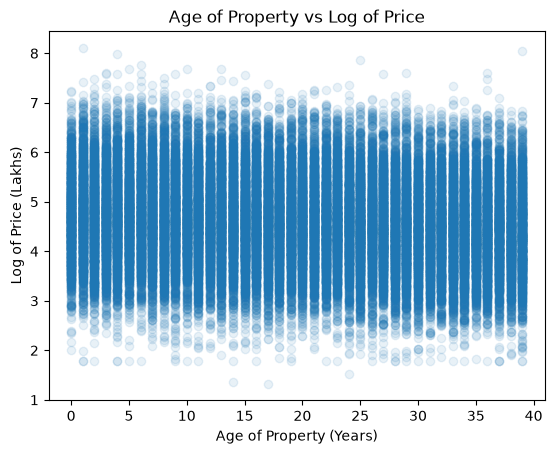

In [ ]:
plt.Figure(figsize=(8, 5))

plt.scatter(
    X_train["Age_of_Property"],
    y_train_log,
    alpha=0.1
)

plt.xlabel("Age of Property (Years)")
plt.ylabel("Log of Price (Lakhs)")
plt.title("Age of Property vs Log of Price")
plt.show()

In [ ]:
age_index = processed_feature_names.index("Age_of_Property")

print(age_index)

6


In [ ]:
train_age_squared = (
    X_train_processed[:, age_index] ** 2
)

test_age_squared = (
    X_test_processed[:, age_index] ** 2
)

In [ ]:
X_train_age_poly = np.column_stack([
    X_train_log_poly_no_carpet,
    train_age_squared
])

X_test_age_poly = np.column_stack([
    X_test_log_poly_no_carpet,
    test_age_squared
])

print(X_train_age_poly.shape)
print(X_test_age_poly.shape)

(64000, 29)
(16000, 29)


In [ ]:
X_train_age_poly_bias = np.c_[
    np.ones(X_train_age_poly.shape[0]),
    X_train_age_poly
]

X_test_age_poly_bias = np.c_[
    np.ones(X_test_age_poly.shape[0]),
    X_test_age_poly
]

In [ ]:
model_log_age_poly = LinearRegression()

model_log_age_poly.fit(
    X_train_age_poly_bias,
    y_train_log
)

In [ ]:
y_pred_log_age_poly = model_log_age_poly.predict(
    X_test_age_poly_bias
)

In [ ]:
y_pred_age_poly_original = np.expm1(
    y_pred_log_age_poly
)

In [ ]:
errors_age_poly = (
    y_test.to_numpy()
    - y_pred_age_poly_original
)

mae_age_poly = np.mean(
    np.abs(errors_age_poly)
)

mse_age_poly = np.mean(
    errors_age_poly ** 2
)

rmse_age_poly = np.sqrt(
    mse_age_poly
)

y_test_array = y_test.to_numpy()
y_mean = np.mean(y_test_array)

ss_res = np.sum(
    (y_test_array - y_pred_age_poly_original) ** 2
)

ss_tot = np.sum(
    (y_test_array - y_mean) ** 2
)

r2_age_poly = 1 - (
    ss_res / ss_tot
)

print("MAE :", mae_age_poly)
print("RMSE:", rmse_age_poly)
print("R²  :", r2_age_poly)

MAE : 32.171776405015436
RMSE: 68.45671961017919
R²  : 0.788332656927746


In [ ]:
X_train_no_bhk, X_test_no_bhk, current_feature_names = remove_feature(
    X_train_log_poly_no_carpet,
    X_test_log_poly_no_carpet,
    current_feature_names,
    "BHK"
)

In [ ]:
print(X_train_no_bhk.shape)
print(X_test_no_bhk.shape)

(64000, 27)
(16000, 27)


In [ ]:
X_train_no_bhk_bias = np.c_[
    np.ones(X_train_no_bhk.shape[0]),
    X_train_no_bhk
]

X_test_no_bhk_bias = np.c_[
    np.ones(X_test_no_bhk.shape[0]),
    X_test_no_bhk
]

print(X_train_no_bhk_bias.shape)
print(X_test_no_bhk_bias.shape)

(64000, 28)
(16000, 28)


In [ ]:
model_no_bhk = LinearRegression()
model_no_bhk.fit(
    X_train_no_bhk_bias,
    y_train_log
)

In [ ]:
y_pred_log_no_bhk = model_no_bhk.predict(
    X_test_no_bhk_bias
)

In [ ]:
y_pred_no_bhk_original = np.expm1(
    y_pred_log_no_bhk
)

In [ ]:
error_no_bhk = ( y_test.to_numpy() - y_pred_no_bhk_original)

mae_no_bhk = np.mean(np.abs(error_no_bhk))
rmse_no_bhk = np.sqrt(np.mean(error_no_bhk ** 2))
mse_no_bhk = np.mean(error_no_bhk ** 2)

ss_res = np.sum(
    (y_test.to_numpy() - y_pred_no_bhk_original) ** 2
)

ss_tot = np.sum(
    (y_test.to_numpy() - np.mean(y_test.to_numpy())) ** 2
)

r2_no_bhk = 1 - (
    ss_res / ss_tot
)

print("MAE :", mae_no_bhk)
print("RMSE:", rmse_no_bhk)
print("R²  :", r2_no_bhk)

MAE : 32.16383087411662
RMSE: 68.42046621557296
R²  : 0.7885567876732511


In [ ]:
X_train_no_bath, X_test_no_bath, current_feature_names = remove_feature(
    X_train_no_bhk,
    X_test_no_bhk,
    current_feature_names,
    "Bathrooms"
)

In [ ]:
print(X_train_no_bath.shape)
print(X_test_no_bath.shape)

(64000, 26)
(16000, 26)


In [ ]:
X_train_no_bath_bias = np.c_[
    np.ones(X_train_no_bath.shape[0]),
    X_train_no_bath
]

X_test_no_bath_bias = np.c_[
    np.ones(X_test_no_bath.shape[0]),
    X_test_no_bath
]

print(X_train_no_bath_bias.shape)
print(X_test_no_bath_bias.shape)

(64000, 27)
(16000, 27)


In [ ]:
model_no_bath = LinearRegression()
model_no_bath.fit(X_train_no_bath_bias, y_train_log)

In [ ]:
y_pred_log_no_bath = model_no_bath.predict(
    X_test_no_bath_bias
)

In [ ]:
y_pred_log_no_bath = model_no_bath.predict(X_test_no_bath_bias)

In [ ]:
y_pred_log_no_bath_org = np.expm1(y_pred_log_no_bath)

print(y_pred_log_no_bath[:10])

[5.8561188  4.29313312 3.75950646 3.88027177 4.78407228 4.4597492
 5.80335896 4.76917612 5.02514842 5.04354334]


In [ ]:
errors_no_bath = y_test.to_numpy() - y_pred_log_no_bath_org

mae_no_bath = np.mean(np.abs(errors_no_bath))
mse_no_bath = np.mean(errors_no_bath ** 2)
rmse_no_bath = np.sqrt(mse_no_bath)

ss_res = np.sum(
    (y_test.to_numpy() - y_pred_log_no_bath_org) ** 2
)

ss_tot = np.sum(
    (y_test.to_numpy() - np.mean(y_test.to_numpy())) ** 2
)

r2 = 1 - (ss_res / ss_tot)

print("MAE :", mae_no_bath)
print("RMSE:", rmse_no_bath)
print("R²  :", r2)

MAE : 32.16192183793038
RMSE: 68.41585123118891
R²  : 0.7885853105485751


In [ ]:
X_train_no_floor, X_test_no_floor, current_feature_names = remove_feature(
    X_train_no_bath,
    X_test_no_bath,
    current_feature_names,
    "Floor_Number"
)

In [ ]:
X_train_no_floor_bias = np.c_[
    np.ones(X_train_no_bath.shape[0]),
    X_train_no_floor
]

X_test_no_floor_bias = np.c_[
    np.ones(X_test_no_floor.shape[0]),
    X_test_no_floor
]

print(X_train_no_floor_bias.shape)
print(X_test_no_floor_bias.shape)

(64000, 26)
(16000, 26)


In [ ]:
model_no_floor = LinearRegression()
model_no_floor.fit(
    X_train_no_floor_bias, y_train_log 
)

In [ ]:
y_pred_no_floor = model_no_floor.predict(X_test_no_floor_bias)

In [ ]:
y_pred_no_floor_org = np.expm1(y_pred_no_floor)

In [ ]:
error_no_floor = y_test.to_numpy() - y_pred_no_floor_org

mae_no_floor = np.mean(np.abs(error_no_floor))
mse_no_floor = np.mean(error_no_floor ** 2)
rmse_no_floor = np.sqrt(mse)

ss_res = np.sum(
    (y_test.to_numpy() - y_pred_no_floor_org) ** 2
)

ss_tot = np.sum(
    (y_test.to_numpy() - np.mean(y_test.to_numpy())) ** 2
)

r2_no_floor = 1 - (ss_res/ss_tot)

print("MAE :", mae_no_floor)
print("RMSE:", rmse_no_bath)
print("R²  :", r2_no_floor)

MAE : 32.16231901838588
RMSE: 68.41585123118891
R²  : 0.788569449241205


In [ ]:
X_train_no_total_floor, X_test_no_total_floor, current_feature_names = remove_feature(
    X_train_no_floor,
    X_test_no_floor,
    current_feature_names,
    "Total_Floors"
)

In [ ]:
X_train_no_total_floor_bias = np.c_[
    np.ones(X_train_no_total_floor.shape[0]),
    X_train_no_total_floor
]

X_test_no_total_floor_bias = np.c_[
    np.ones(X_test_no_total_floor.shape[0]),
    X_test_no_total_floor
]

print(X_train_no_total_floor_bias.shape)
print(X_test_no_total_floor_bias.shape)


(64000, 25)
(16000, 25)


In [ ]:
model_no_total_floor = LinearRegression()
model_no_total_floor.fit(
    X_train_no_total_floor_bias, y_train_log
)

In [ ]:
y_pred_no_total_floor = model_no_total_floor.predict(X_test_no_total_floor_bias)

In [ ]:
y_pred_no_total_floor_org = np.expm1(y_pred_no_total_floor)

In [ ]:
error_no_total_floor = y_test.to_numpy() - y_pred_no_total_floor_org
mae_no_total_floor = np.mean(np.abs(error_no_total_floor))
mse_no_total_floor = np.mean(error_no_total_floor ** 2)
rmse_no_total_floor = np.sqrt(mse_no_total_floor)

ss_res = np.sum(
    (y_test.to_numpy() - y_pred_no_total_floor_org) ** 2
)

ss_tot = np.sum(
    (y_test.to_numpy() - np.mean(y_test.to_numpy())) ** 2
)

r2_no_total_floor = 1 - (ss_res/ss_tot)

print("MAE :", mae_no_total_floor)
print("RMSE:", rmse_no_total_floor)
print("R²  :", r2_no_total_floor)

MAE : 32.163577180109975
RMSE: 68.42103688421723
R²  : 0.7885532605264426


In [ ]:
print("current_feature_names:", current_feature_names)
print("Number of features:", len(current_feature_names))

current_feature_names: ['Super_Area_SqFt', 'Age_of_Property', 'Parking', 'Lift_Available', 'Gated_Community', 'Distance_to_Metro_km', 'Distance_to_City_Center_km', 'City_Bangalore', 'City_Chandigarh', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Jaipur', 'City_Kolkata', 'City_Mumbai', 'City_Pune', 'Locality_Type_Mid-Range', 'Locality_Type_Premium', 'Property_Type_Builder Floor', 'Property_Type_Independent House', 'Property_Type_Villa', 'Furnishing_Status_Semi-Furnished', 'Furnishing_Status_Unfurnished']
Number of features: 23


In [ ]:
X_train_no_parking, X_test_no_parking, current_feature_names = remove_feature(
    X_train_no_total_floor,
    X_test_no_total_floor,
    current_feature_names,
    "Parking"
)

print(X_train_no_parking.shape)
print(X_test_no_parking.shape)
print("Parking" in current_feature_names)

(64000, 23)
(16000, 23)
False


In [ ]:
X_train_no_parking_bias = np.c_[
    np.ones(X_train_no_parking.shape[0]),
    X_train_no_parking
]

X_test_no_parking_bias = np.c_[
    np.ones(X_test_no_parking.shape[0]),
    X_test_no_parking
]

print(X_train_no_parking_bias.shape)
print(X_test_no_parking_bias.shape)

(64000, 24)
(16000, 24)


In [ ]:
model_no_parking = LinearRegression()
model_no_parking.fit(
    X_train_no_parking_bias, y_train_log
)

In [ ]:
y_pred_no_parking = model_no_parking.predict(X_test_no_parking_bias)

In [ ]:
y_pred_no_parking_org = np.expm1(y_pred_no_parking)

In [ ]:
error_no_parking = y_test.to_numpy() - np.expm1(y_pred_no_parking)
mae_no_parking = np.mean(np.abs(error_no_parking))
mse_no_parking = np.mean(error_no_parking ** 2)
rmse_no_parking = np.sqrt(mse_no_parking)

ss_res = np.sum(
    (y_test.to_numpy() - y_pred_no_parking_org) ** 2
)
ss_tot = np.sum(
    (y_test.to_numpy() - np.mean(y_test.to_numpy())) ** 2
)
r2_no_parking = 1 - (ss_res/ss_tot)

print("MAE :", mae_no_parking)
print("RMSE:", rmse_no_parking)
print("R²  :", r2_no_parking)

MAE : 32.17186549448344
RMSE: 68.444023824213
R²  : 0.7884111600786733


In [ ]:
X_train_no_lift, X_test_no_lift, current_feature_names = remove_feature(
    X_train_no_parking,
    X_test_no_parking,
    current_feature_names,
    "Lift_Available"
)

print(X_train_no_lift.shape)
print(X_test_no_lift.shape)
print("Lift_Available" in current_feature_names)

(64000, 22)
(16000, 22)
False


In [ ]:
X_train_no_lift_bias = np.c_[
    np.ones(X_train_no_lift.shape[0]),
    X_train_no_lift
]
X_test_no_lift_bias = np.c_[
    np.ones(X_test_no_lift.shape[0]),
    X_test_no_lift
]

print(X_train_no_lift_bias.shape)
print(X_test_no_lift_bias.shape)

(64000, 23)
(16000, 23)


In [ ]:
model_no_lift = LinearRegression()
model_no_lift.fit(
    X_train_no_lift_bias, y_train_log
)

In [ ]:
y_pred_no_lift = model_no_lift.predict(X_test_no_lift_bias)

In [ ]:
y_pred_no_lift_org = np.expm1(y_pred_no_lift)

In [ ]:
error_no_lift = y_test.to_numpy() - y_pred_no_lift_org
mae_no_lift = np.mean(np.abs(error_no_lift))
mse_no_lift = np.mean(error_no_lift ** 2)
rmse_no_lift = np.sqrt(mse_no_lift)

ss_res = np.sum(
    (y_test.to_numpy() - y_pred_no_lift_org) ** 2
)
ss_tot = np.sum(
    (y_test.to_numpy() - np.mean(y_test.to_numpy())) ** 2
)

r2_no_lift = 1 - (ss_res/ss_tot)

print("MAE :", mae_no_lift)
print("RMSE:", rmse_no_lift)
print("R²  :", r2_no_lift)

MAE : 32.180553270580056
RMSE: 68.46959608494859
R²  : 0.7882530216326441


In [ ]:
X_train_no_gated, X_test_no_gated, current_feature_names = remove_feature(
    X_train_no_lift,
    X_test_no_lift,
    current_feature_names,
    "Gated_Community"
)

print(X_train_no_gated.shape)
print(X_test_no_gated.shape)
print("Gated_Community" in current_feature_names)

(64000, 21)
(16000, 21)
False


In [ ]:
X_train_no_gated_bias = np.c_[
    np.ones(X_train_no_gated.shape[0]),
    X_train_no_gated
]
X_test_no_gated_bias = np.c_[
    np.ones(X_test_no_gated.shape[0]),
    X_test_no_gated
]   

print(X_train_no_gated_bias.shape)
print(X_test_no_gated_bias.shape)

(64000, 22)
(16000, 22)


In [ ]:
model_no_gated = LinearRegression()
model_no_gated.fit(
    X_train_no_gated_bias, y_train_log
)

In [ ]:
y_pred_no_gated = model_no_gated.predict(X_test_no_gated_bias)

In [ ]:
y_pred_no_gated_org = np.expm1(y_pred_no_gated)

In [ ]:
error_no_gated = y_test.to_numpy() - y_pred_no_gated_org
mae_no_gated = np.mean(np.abs(error_no_gated))
mse_no_gated = np.mean(error_no_gated ** 2)
rmse_no_gated = np.sqrt(mse_no_gated)
ss_res = np.sum(
    (y_test.to_numpy() - y_pred_no_gated_org) ** 2
)
ss_tot = np.sum(
    (y_test.to_numpy() - np.mean(y_test.to_numpy())) ** 2
)
r2_no_gated = 1 - (ss_res/ss_tot)   

print("MAE :", mae_no_gated)
print("RMSE:", rmse_no_gated)
print("R²  :", r2_no_gated)

MAE : 32.176445100716705
RMSE: 68.46318419292575
R²  : 0.7882926782179803


In [ ]:
X_train_no_metro, X_test_no_metro, current_feature_names = remove_feature(
    X_train_no_gated,
    X_test_no_gated,
    current_feature_names,
    "Distance_to_Metro_km"
)

print(X_train_no_metro.shape)
print(X_test_no_metro.shape)

(64000, 20)
(16000, 20)


In [ ]:
X_train_no_metro_bias = np.c_[
    np.ones(X_train_no_metro.shape[0]),
    X_train_no_metro
]  

X_test_no_metro_bias = np.c_[
    np.ones(X_test_no_metro.shape[0]),
    X_test_no_metro
]

print(X_train_no_metro_bias.shape)
print(X_test_no_metro_bias.shape)

(64000, 21)
(16000, 21)


In [ ]:
model_no_metro = LinearRegression()
model_no_metro.fit(
    X_train_no_metro_bias, y_train_log
)

In [ ]:
y_pred_no_metro = model_no_metro.predict(X_test_no_metro_bias)

In [ ]:
y_pred_no_metro_org = np.expm1(y_pred_no_metro)

In [ ]:
error_no_metro = y_test.to_numpy() - y_pred_no_metro_org
mae_no_metro = np.mean(np.abs(error_no_metro))
mse_no_metro = np.mean(error_no_metro ** 2)
rmse_no_metro = np.sqrt(mse_no_metro)

ss_res = np.sum(
    (y_test.to_numpy() - y_pred_no_metro_org) ** 2
)
ss_tot = np.sum(
    (y_test.to_numpy() - np.mean(y_test.to_numpy())) ** 2
)
r2_no_metro = 1 - (ss_res/ss_tot)

print("MAE :", mae_no_metro)
print("RMSE:", rmse_no_metro)
print("R²  :", r2_no_metro)

MAE : 32.17713842499487
RMSE: 68.47216205053002
R²  : 0.7882371504819278


In [ ]:
X_train_no_city_center, X_test_no_city_center, current_feature_names = remove_feature(
    X_train_no_metro,
    X_test_no_metro,
    current_feature_names,
    "Distance_to_City_Center_km"
)

print(X_train_no_city_center.shape)
print(X_test_no_city_center.shape)
print("Distance_to_City_Center_km" in current_feature_names)

(64000, 19)
(16000, 19)
False


In [ ]:
X_train_no_city_centre_bias = np.c_[
    np.ones(X_train_no_city_center.shape[0]),
    X_train_no_city_center
]
X_test_no_city_centre_bias = np.c_[
    np.ones(X_test_no_city_center.shape[0]),
    X_test_no_city_center
]

print(X_train_no_city_centre_bias.shape)
print(X_test_no_city_centre_bias.shape)

(64000, 20)
(16000, 20)


In [ ]:
model_no_city_center = LinearRegression()
model_no_city_center.fit(
    X_train_no_city_centre_bias, y_train_log
)

In [ ]:
y_pred_no_city_center = model_no_city_center.predict(X_test_no_city_centre_bias)

In [ ]:
y_pred_no_city_center_org = np.expm1(y_pred_no_city_center)

In [ ]:
error_no_city_center = y_test.to_numpy() - y_pred_no_city_center_org
mae_no_city_center = np.mean(np.abs(error_no_city_center))
mse_no_city_center = np.mean(error_no_city_center ** 2)
rmse_no_city_center = np.sqrt(mse_no_city_center)

ss_res = np.sum(
    (y_test.to_numpy() - y_pred_no_city_center_org) ** 2
)
ss_tot = np.sum(
    (y_test.to_numpy() - np.mean(y_test.to_numpy())) ** 2
)
r2_no_city_center = 1 - (ss_res/ss_tot)

print("MAE :", mae_no_city_center)
print("RMSE:", rmse_no_city_center)
print("R²  :", r2_no_city_center)  

MAE : 34.012172328416035
RMSE: 71.36273630627937
R²  : 0.7699804878024521


In [ ]:
keep_features = [
    "Super_Area_SqFt",
    "Age_of_Property",
    "Distance_to_City_Center_km"
]

keep_features += [
    feature
    for feature in processed_feature_names
    if feature.startswith("City_")
    or feature.startswith("Locality_Type_")
    or feature.startswith("Property_Type_")
    or feature.startswith("Furnishing_Status_")
]

print("Number of base features:", len(keep_features))
print(keep_features)

Number of base features: 19
['Super_Area_SqFt', 'Age_of_Property', 'Distance_to_City_Center_km', 'City_Bangalore', 'City_Chandigarh', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Jaipur', 'City_Kolkata', 'City_Mumbai', 'City_Pune', 'Locality_Type_Mid-Range', 'Locality_Type_Premium', 'Property_Type_Builder Floor', 'Property_Type_Independent House', 'Property_Type_Villa', 'Furnishing_Status_Semi-Furnished', 'Furnishing_Status_Unfurnished']


In [ ]:
keep_indices = [
    processed_feature_names.index(feature)
    for feature in keep_features
]

X_train_clean = X_train_processed[:, keep_indices]
X_test_clean = X_test_processed[:, keep_indices]

print(X_train_clean.shape)
print(X_test_clean.shape)

(64000, 19)
(16000, 19)


In [ ]:
area_clean_index = keep_features.index("Super_Area_SqFt")

print(area_clean_index)

0


In [ ]:
train_area_squared_clean = (
    X_train_clean[:, area_clean_index] ** 2
)

test_area_squared_clean = (
    X_test_clean[:, area_clean_index] ** 2
)

In [ ]:
X_train_final = np.column_stack([
    X_train_clean,
    train_area_squared_clean
])

X_test_final = np.column_stack([
    X_test_clean,
    test_area_squared_clean
])

print(X_train_final.shape)
print(X_test_final.shape)

(64000, 20)
(16000, 20)


In [ ]:
final_feature_names = keep_features + ["Super_Area_SqFt²"]

print(len(final_feature_names))
print(final_feature_names)

20
['Super_Area_SqFt', 'Age_of_Property', 'Distance_to_City_Center_km', 'City_Bangalore', 'City_Chandigarh', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Jaipur', 'City_Kolkata', 'City_Mumbai', 'City_Pune', 'Locality_Type_Mid-Range', 'Locality_Type_Premium', 'Property_Type_Builder Floor', 'Property_Type_Independent House', 'Property_Type_Villa', 'Furnishing_Status_Semi-Furnished', 'Furnishing_Status_Unfurnished', 'Super_Area_SqFt²']


In [ ]:
X_train_final_bias = np.c_[
    np.ones(X_train_final.shape[0]),
    X_train_final
]

X_test_final_bias = np.c_[
    np.ones(X_test_final.shape[0]),
    X_test_final
]

print(X_train_final_bias.shape)
print(X_test_final_bias.shape)

(64000, 21)
(16000, 21)


In [ ]:
model_final_base = LinearRegression()

model_final_base.fit(
    X_train_final_bias,
    y_train_log
)

print("Number of parameters:", len(model_final_base.theta))

Number of parameters: 21


In [ ]:
y_pred_log_final_base = model_final_base.predict(
    X_test_final_bias
)

y_pred_final_base = np.expm1(
    y_pred_log_final_base
)

In [ ]:
errors_final_base = (
    y_test.to_numpy()
    - y_pred_final_base
)

mae_final_base = np.mean(
    np.abs(errors_final_base)
)

mse_final_base = np.mean(
    errors_final_base ** 2
)

rmse_final_base = np.sqrt(
    mse_final_base
)

y_test_array = y_test.to_numpy()
y_mean = np.mean(y_test_array)

ss_res = np.sum(
    (y_test_array - y_pred_final_base) ** 2
)

ss_tot = np.sum(
    (y_test_array - y_mean) ** 2
)

r2_final_base = 1 - (
    ss_res / ss_tot
)

print("MAE :", mae_final_base)
print("RMSE:", rmse_final_base)
print("R²  :", r2_final_base)

MAE : 32.17713842499487
RMSE: 68.47216205052986
R²  : 0.7882371504819287


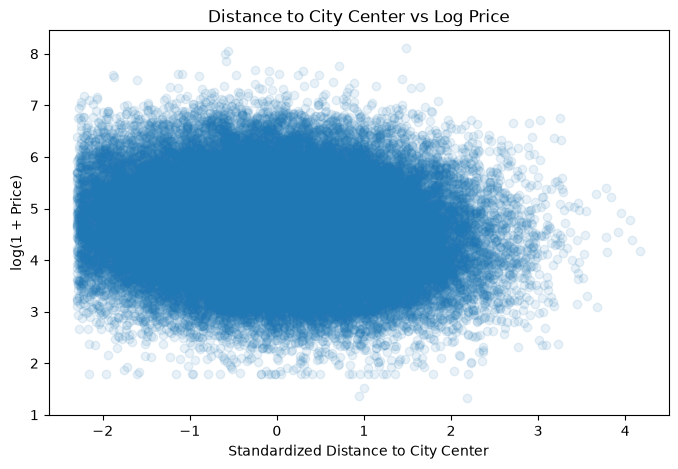

In [ ]:
distance_index = final_feature_names.index(
    "Distance_to_City_Center_km"
)

plt.figure(figsize=(8, 5))

plt.scatter(
    X_train_final[:, distance_index],
    y_train_log,
    alpha=0.1
)

plt.xlabel("Standardized Distance to City Center")
plt.ylabel("log(1 + Price)")
plt.title("Distance to City Center vs Log Price")

plt.show()

In [ ]:
distance_index = final_feature_names.index(
    "Distance_to_City_Center_km"
)

print(distance_index)

2


In [ ]:
train_distance_squared = (
    X_train_final[:, distance_index] ** 2
)

test_distance_squared = (
    X_test_final[:, distance_index] ** 2
)

In [ ]:
X_train_distance_poly = np.column_stack([
    X_train_final,
    train_distance_squared
])

X_test_distance_poly = np.column_stack([
    X_test_final,
    test_distance_squared
])

print(X_train_distance_poly.shape)
print(X_test_distance_poly.shape)

(64000, 21)
(16000, 21)


In [ ]:
X_train_distance_poly_bias = np.c_[
    np.ones(X_train_distance_poly.shape[0]),
    X_train_distance_poly
]
X_test_distance_poly_bias = np.c_[
    np.ones(X_test_distance_poly.shape[0]),
    X_test_distance_poly
]

print(X_train_distance_poly_bias.shape)
print(X_test_distance_poly_bias.shape)

(64000, 22)
(16000, 22)


In [ ]:
model_distance_poly = LinearRegression()
model_distance_poly.fit(
    X_train_distance_poly_bias,
    y_train_log
)

In [ ]:
y_pred_distance_poly = model_distance_poly.predict(
    X_test_distance_poly_bias
)

In [ ]:
y_pred_distance_poly_org = np.expm1(y_pred_distance_poly)

In [ ]:
errors_distance_poly = (
    y_test.to_numpy()
    - y_pred_distance_poly_org
)

mae_distance_poly = np.mean(
    np.abs(errors_distance_poly)
)   

mse_distance_poly = np.mean(
    errors_distance_poly ** 2
)

rmse_distance_poly = np.sqrt(
    mse_distance_poly
)

ss_res = np.sum(
    (y_test.to_numpy() - y_pred_distance_poly_org) ** 2
)

ss_tot = np.sum(
    (y_test.to_numpy() - np.mean(y_test.to_numpy())) ** 2
)

r2_distance_poly = 1 - (ss_res/ss_tot)

print("MAE :", mae_distance_poly)
print("RMSE:", rmse_distance_poly)
print("R²  :", r2_distance_poly)

MAE : 32.176285192802155
RMSE: 68.47320500830345
R²  : 0.7882306993524332


In [ ]:
residuals = (
    y_test.to_numpy()
    - y_pred_final_base
)

print("Mean residual:", np.mean(residuals))
print("Min residual:", np.min(residuals))
print("Max residual:", np.max(residuals))

Mean residual: 6.365551018674204
Min residual: -348.7776383911123
Max residual: 2277.16644866336


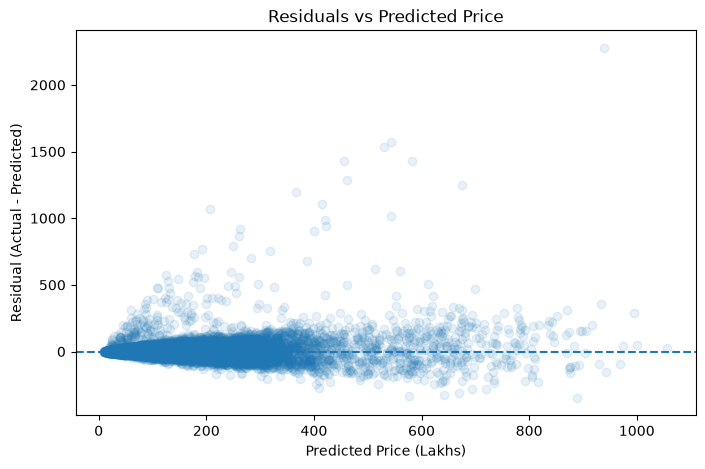

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_final_base,
    residuals,
    alpha=0.1
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Price (Lakhs)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted Price")

plt.show()

# Decision Tree Regression

In [ ]:
tree_numeric_features = [
    "Super_Area_SqFt",
    "Age_of_Property",
    "Distance_to_City_Center_km"
]

In [ ]:
tree_categorical_features = [
    "City",
    "Locality_Type",
    "Property_Type",
    "Furnishing_Status"
]

In [ ]:
X_train_tree_cat = encoder.transform(
    X_train[tree_categorical_features]
)

X_test_tree_cat = encoder.transform(
    X_test[tree_categorical_features]
)

In [ ]:
X_train_tree_num = X_train[
    tree_numeric_features
].to_numpy()

X_test_tree_num = X_test[
    tree_numeric_features
].to_numpy()

In [ ]:
X_train_tree = np.hstack([
    X_train_tree_num,
    X_train_tree_cat.toarray()
])

X_test_tree = np.hstack([
    X_test_tree_num,
    X_test_tree_cat.toarray()
])

print(X_train_tree.shape)
print(X_test_tree.shape)

(64000, 19)
(16000, 19)


In [ ]:
max_depth = None

In [ ]:
class Node:

    def __init__(self,feature_index=None,threshold=None,prediction=None):
        self.feature_index = feature_index
        self.threshold = threshold
        self.prediction = prediction
        self.left = None
        self.right = None

In [ ]:
class DecisionTreeRegression:
  
    def fit(self,X,y):
      
        def calculate_sse(y):
            mean_y = np.mean(y)
            sse = np.sum((y-mean_y)**2)
            return sse
      
        def calculate_split_sse(X,y,threshold):
        
            left_mask = X < threshold
            right_mask = X >= threshold

            left_y = y[left_mask]
            right_y = y[right_mask]

            left_sse = calculate_sse(left_y)
            right_sse = calculate_sse(right_y)

            return left_sse + right_sse
      
        def find_best_split(X,y):
            min_sse = np.inf
            best_threshold = None

            for i in range(len(X)-1):
                threshold = (X[i] + X[i+1])/2
                sse = calculate_split_sse(X,y,threshold)
                if sse < min_sse:
                    min_sse = sse
                    best_threshold = threshold
        
            return best_threshold, min_sse

        def split_data(X, y, threshold):

            left_mask = X < threshold
            right_mask = X >= threshold

            X_left = X[left_mask]
            y_left = y[left_mask]

            X_right = X[right_mask]
            y_right = y[right_mask]

            

        def create_leaf(y):
            return np.mean(y)



        def build_tree(X, y):
            if len(y) == 1:
                prediction = create_leaf(y)
                return Node(prediction=prediction)

            best_threshold, min_sse = find_best_split(X, y)

            X_left, y_left, X_right, y_right = split_data(
                    X,
                    y,
                    best_threshold
                )
            
            node = Node(threshold=best_threshold)

            node.left = build_tree(X_left, y_left)

            node.right = build_tree(X_right, y_right)
            
        
            return node
        
        self.root = build_tree(X,y)
        
        
    def predict_one(self, X, node):

        if node.prediction is not None:
            return node.prediction

        if X < node.threshold:
            return self.predict_one(X, node.left)

        else:
            return self.predict_one(X, node.right)



In [1]:
print("Decision Tree Regression model created successfully not successfully.")

Decision Tree Regression model created successfully not successfully.
